# 区分別出願件数集計

`goods-and-service-name-and-code` から区分番号を抽出し、**企業 × 出願年 × 区分** で件数を集計するノートブック。

In [1]:
import os

import pandas as pd
from utils.db import get_conn, DB_CONFIG

print('DB設定を読み込みました:', DB_CONFIG['host'], DB_CONFIG['dbname'])

DB設定を読み込みました: 172.18.106.203 trademark_db


---

## 1. ユーティリティ関数の読み込み

`trademark_utils.py` から以下の関数をインポートする。

| 関数 | 説明 |
|---|---|
| `parse_filing_date(text)` | 出願日文字列（和暦）→ `datetime.date` |
| `extract_classes(text)` | 指定商品・役務文字列 → 区分番号の整数リスト |

In [2]:
from utils.trademark_utils import parse_filing_date, extract_classes

print('utils.trademark_utils を読み込みました')

utils.trademark_utils を読み込みました


---

## 2. データ取得

対象企業の `company_id` と対象年（西暦）を入力してからセルを実行してください。  
どちらかが未入力の場合はエラーで停止します。

In [4]:
# ===== 検索条件を入力 =====
target_company_id = 709006024   # 例: 131094
target_year       = 2020   # 例: 2020  （西暦4桁の整数）
# ==========================

# --- 入力値の検証 ---
_errors = []
if target_company_id is None:
    _errors.append('  • target_company_id が未設定です（整数で入力してください）')
if target_year is None:
    _errors.append('  • target_year が未設定です（西暦4桁の整数で入力してください）')
if _errors:
    raise ValueError(
        '以下の入力が不足しています。値を設定してからセルを再実行してください。\n'
        + '\n'.join(_errors)
    )

print(f'対象企業ID : {target_company_id}')
print(f'対象年     : {target_year}')

対象企業ID : 709006024
対象年     : 2020


In [5]:
# company_id でフィルタして取得（年は Python 側でフィルタ）
with get_conn() as conn:
    df_fetched = pd.read_sql("""
        SELECT
            "right-holder-group-identification-number"  AS company_id,
            "right-holder-group-name"                   AS company_name,
            "filing-date"                               AS filing_date_raw,
            "goods-and-service-name-and-code"           AS goods_and_service
        FROM trademark_db
        WHERE "goods-and-service-name-and-code"               IS NOT NULL
          AND "filing-date"                                    IS NOT NULL
          AND "right-holder-group-identification-number"      = %(company_id)s
    """, conn, params={'company_id': target_company_id})

if df_fetched.empty:
    raise ValueError(
        f'company_id={target_company_id} に該当するデータが見つかりませんでした。'
        ' company_id を確認してください。'
    )

# 出願日をパースして target_year でフィルタ
df_fetched['filing_date'] = df_fetched['filing_date_raw'].apply(parse_filing_date)
df_fetched['filing_year'] = df_fetched['filing_date'].apply(lambda d: d.year if d else None)
df_raw = df_fetched[df_fetched['filing_year'] == target_year].copy()

if df_raw.empty:
    raise ValueError(
        f'company_id={target_company_id}、{target_year}年 の出願データが見つかりませんでした。'
        f' 対象企業の出願年一覧: {sorted(df_fetched["filing_year"].dropna().astype(int).unique().tolist())}'
    )

company_name = df_raw['company_name'].iloc[0]
print(f'企業名   : {company_name}（ID: {target_company_id}）')
print(f'取得件数 : {len(df_raw):,} 件（{target_year}年）')
df_raw.head(3)

C:\Users\k-fukuzawa\AppData\Local\Temp\ipykernel_49184\4033017769.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_fetched = pd.read_sql("""


企業名   : 株式会社ベネッセコーポレーション（ID: 709006024）
取得件数 : 21 件（2020年）


,company_id,company_name,filing_date_raw,goods_and_service,filing_date,filing_year
5,709006024,株式会社ベネッセコーポレーション,令和２年３月１９日（２０２０．３．１９）,第９類 学習教材用のアプリケーションソフトウェア，アプリケーションソフトウェア，電気通信機...,2020-03-19,2020
6,709006024,株式会社ベネッセコーポレーション,令和２年１０月２０日（２０２０．１０．２０）,第１６類 雑誌，新聞，定期刊行物,2020-10-20,2020
7,709006024,株式会社ベネッセコーポレーション,令和２年１０月２０日（２０２０．１０．２０）,第１６類 雑誌，新聞，定期刊行物,2020-10-20,2020


---

## 3. 前処理

In [6]:
df = df_raw.copy()

# 区分番号リストを列に追加
df['class_list'] = df['goods_and_service'].apply(extract_classes)

# 区分抽出ゼロ件の確認
n_class_empty = df['class_list'].apply(len).eq(0).sum()
print(f'区分抽出ゼロ件: {n_class_empty:,} 件')

df.head(3)

区分抽出ゼロ件: 0 件


,company_id,company_name,filing_date_raw,goods_and_service,filing_date,filing_year,class_list
5,709006024,株式会社ベネッセコーポレーション,令和２年３月１９日（２０２０．３．１９）,第９類 学習教材用のアプリケーションソフトウェア，アプリケーションソフトウェア，電気通信機...,2020-03-19,2020,"[9, 41, 42]"
6,709006024,株式会社ベネッセコーポレーション,令和２年１０月２０日（２０２０．１０．２０）,第１６類 雑誌，新聞，定期刊行物,2020-10-20,2020,[16]
7,709006024,株式会社ベネッセコーポレーション,令和２年１０月２０日（２０２０．１０．２０）,第１６類 雑誌，新聞，定期刊行物,2020-10-20,2020,[16]


In [7]:
# 1行1区分に展開
df_exploded = (
    df
    .explode('class_list')                   # 区分ごとに行を展開
    .dropna(subset=['class_list'])           # 区分なしは除外
    .rename(columns={'class_list': 'class_number'})
    .astype({'class_number': int, 'filing_year': int})
)

print(f'展開後件数: {len(df_exploded):,} 件')
df_exploded[['company_id', 'company_name', 'filing_year', 'class_number']].head(5)

展開後件数: 77 件


,company_id,company_name,filing_year,class_number
5,709006024,株式会社ベネッセコーポレーション,2020,9
5,709006024,株式会社ベネッセコーポレーション,2020,41
5,709006024,株式会社ベネッセコーポレーション,2020,42
6,709006024,株式会社ベネッセコーポレーション,2020,16
7,709006024,株式会社ベネッセコーポレーション,2020,16


---

## 4. 集計：区分別出願件数

In [8]:
result = (
    df_exploded
    .groupby(['company_id', 'company_name', 'filing_year', 'class_number'])
    .size()
    .reset_index(name='application_count')
    .sort_values('class_number')
    .reset_index(drop=True)
)

print(f'{company_name}（{target_year}年）  集計区分数: {len(result):,} 区分')
result

株式会社ベネッセコーポレーション（2020年）  集計区分数: 14 区分


,company_id,company_name,filing_year,class_number,application_count
0,709006024,株式会社ベネッセコーポレーション,2020,9,17
1,709006024,株式会社ベネッセコーポレーション,2020,16,7
2,709006024,株式会社ベネッセコーポレーション,2020,18,1
3,709006024,株式会社ベネッセコーポレーション,2020,24,1
4,709006024,株式会社ベネッセコーポレーション,2020,25,1
5,709006024,株式会社ベネッセコーポレーション,2020,28,2
6,709006024,株式会社ベネッセコーポレーション,2020,35,6
7,709006024,株式会社ベネッセコーポレーション,2020,36,1
8,709006024,株式会社ベネッセコーポレーション,2020,38,3
9,709006024,株式会社ベネッセコーポレーション,2020,41,18


---

## 5. ピボット表示

行 = 出願年、列 = 区分番号、値 = 出願件数

In [9]:
pivot = (
    result
    .pivot_table(
        index='filing_year',
        columns='class_number',
        values='application_count',
        aggfunc='sum',
        fill_value=0,
    )
)
pivot.columns = [f'第{c}類' for c in pivot.columns]

print(f'{company_name}（ID: {target_company_id}）の区分別出願件数')
pivot

株式会社ベネッセコーポレーション（ID: 709006024）の区分別出願件数


,第9類,第16類,第18類,第24類,第25類,第28類,第35類,第36類,第38類,第41類,第42類,第43類,第44類,第45類
filing_year,,,,,,,,,,,,,,
2020,17,7,1,1,1,2,6,1,3,18,13,2,3,2


---

## 6. 区分別出願件数ヒストグラム

第1類〜第45類を横軸に、出願件数を縦軸に表示する。出願ゼロの区分も含めて全45区分を描画する。

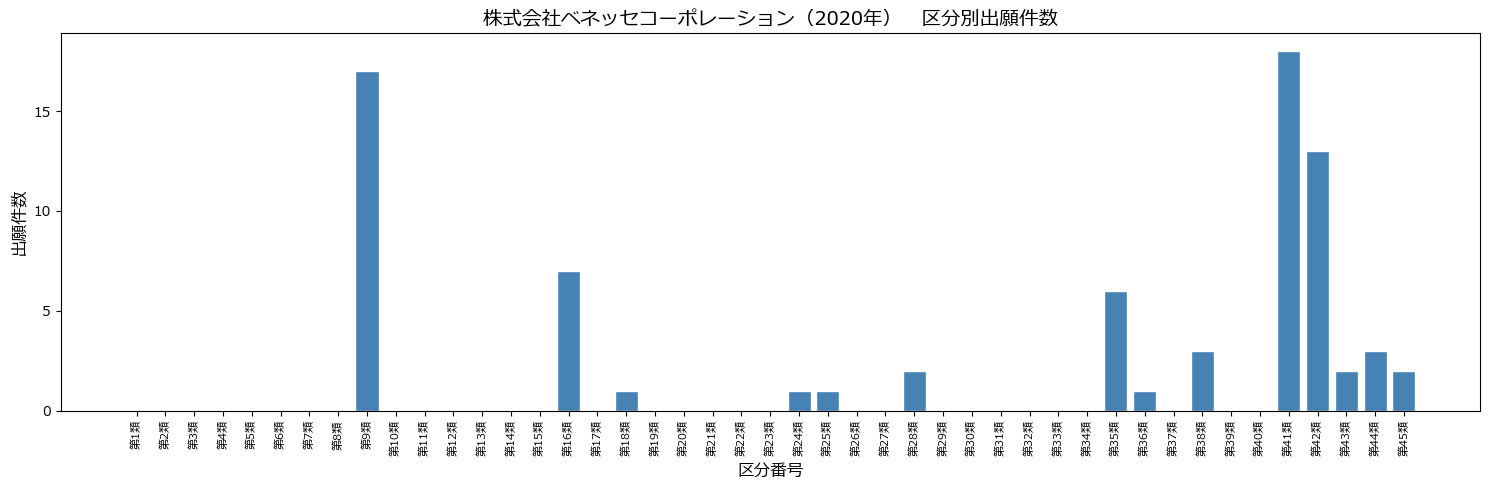

In [10]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Meiryo'  # Windows 日本語フォント

# 第1〜45類すべてを軸に並べ、出願なしは0で埋める
all_classes = range(1, 46)
hist_data = (
    result
    .set_index('class_number')['application_count']
    .reindex(all_classes, fill_value=0)
)

fig, ax = plt.subplots(figsize=(15, 5))
bars = ax.bar(hist_data.index, hist_data.values, color='steelblue', edgecolor='white')

ax.set_xlabel('区分番号', fontsize=12)
ax.set_ylabel('出願件数', fontsize=12)
ax.set_title(f'{company_name}（{target_year}年）　区分別出願件数', fontsize=14)
ax.set_xticks(list(all_classes))
ax.set_xticklabels([f'第{c}類' for c in all_classes], rotation=90, fontsize=8)
ax.yaxis.get_major_locator().set_params(integer=True)  # y軸を整数刻みに

plt.tight_layout()
plt.show()

---

## 7. CSV 出力（任意）

In [ ]:
out_path = f'output/class_filing_{target_company_id}_{target_year}.csv'
os.makedirs('output', exist_ok=True)
result.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'保存しました: {out_path}')

保存しました: output/class_filing_709006024_2020.csv


: 